# Phase 7 — Complete Budget Simulation & Experiments

This notebook ties together all experiments from Phase 7 into a single
narrative. It runs the scripts and displays the results interactively.

**Standalone scripts** (run from the project root):
- `python scripts/exp_convergence.py` → `figures/lln_convergence.png`
- `python scripts/exp_clt_normality.py` → `figures/clt_normality_emergence.png`, `figures/clt_qq_plot.png`
- `python scripts/exp_budget_simulation.py` → `figures/budget_simulation.png`
- `python scripts/exp_variance_reduction.py` → `figures/variance_reduction_comparison.png`
- `python scripts/exp_sensitivity.py` → `figures/sensitivity_tornado.png`
- `python scripts/gen_convergence_gif.py` → `figures/convergence.gif`

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

from src.model import BudgetModel, BudgetModelParams
from src.monte_carlo import MonteCarloSimulator
from src.analysis import compute_ci, prob_over_budget, summary_stats
from src.variance_reduction import control_variate_mc

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
model = BudgetModel()

## 1. Full Budget Simulation (N = 50,000)

In [2]:
simulator = MonteCarloSimulator(
    cost_fn=lambda rng: model.simulate_one_year(rng).total_cost
)
result = simulator.run(n_iterations=50_000, seed=42)

ss = summary_stats(result.samples)
ci = compute_ci(result.samples)
E_a = model.analytical_expected_total()

print(f"Analytical E[X] = R$ {E_a:>14,.2f}")
print(f"MC mean         = R$ {ss['mean']:>14,.2f}")
print(f"Relative error  = {abs(ss['mean'] - E_a)/E_a:.4%}")
print(f"95% CI          = [R$ {ci[0]:,.0f}, R$ {ci[1]:,.0f}]")
print(f"CI half-width   = R$ {(ci[1]-ci[0])/2:,.0f}")
print(f"SD              = R$ {ss['std']:,.0f}")
print(f"P5–P95 range    = [R$ {ss['p5']:,.0f}, R$ {ss['p95']:,.0f}]")
print(f"Skewness        = {ss['skewness']:.4f}")

Analytical E[X] = R$  11,544,339.11
MC mean         = R$  11,542,941.83
Relative error  = 0.0121%
95% CI          = [R$ 11,538,645, R$ 11,547,238]
CI half-width   = R$ 4,296
SD              = R$ 490,161
P5–P95 range    = [R$ 10,754,162, R$ 12,362,379]
Skewness        = 0.1388


In [3]:
CEILING = 12_500_000
p_over = prob_over_budget(result.samples, CEILING)

print(f"\nBudget ceiling = R$ {CEILING:,.0f}")
print(f"P(X > ceiling) = {p_over:.2%}")
print(f"P(X ≤ ceiling) = {1 - p_over:.2%}")


Budget ceiling = R$ 12,500,000
P(X > ceiling) = 2.84%
P(X ≤ ceiling) = 97.16%


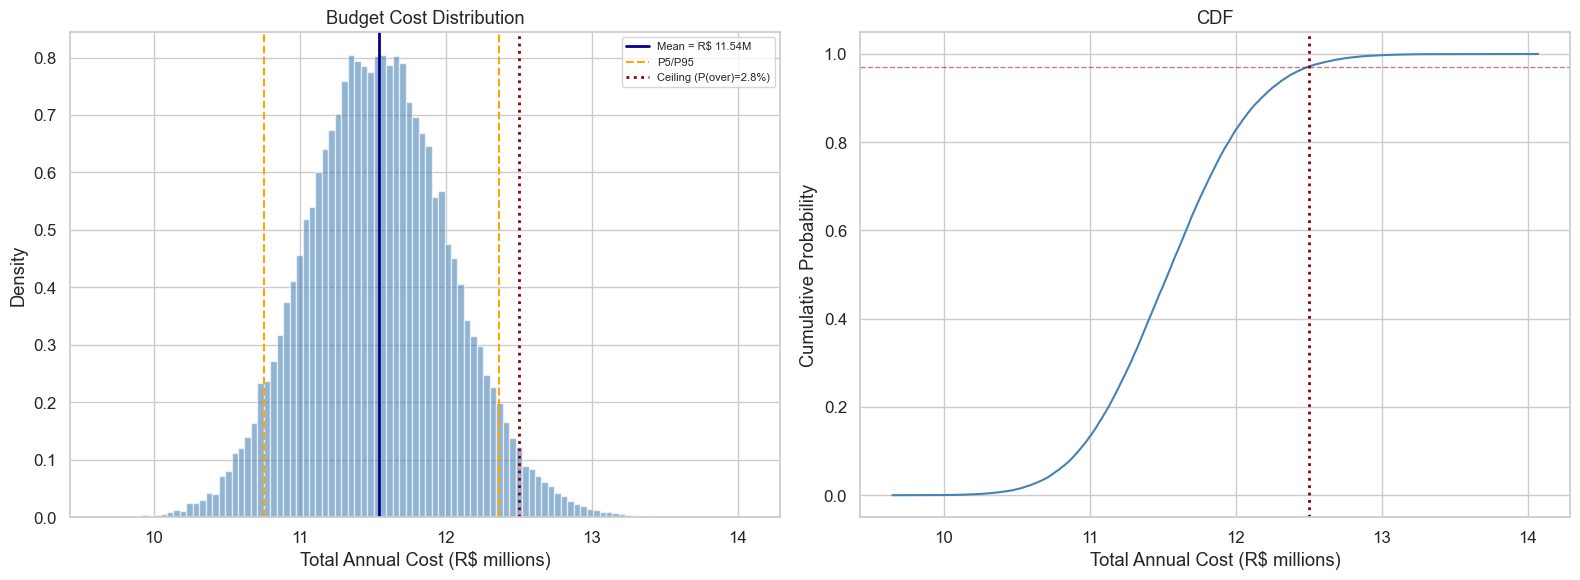

In [4]:
# Dual figure: histogram + CDF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
data_m = result.samples / 1e6

ax1.hist(data_m, bins=100, density=True, alpha=0.6,
         color="steelblue", edgecolor="white")
ax1.axvline(ss["mean"]/1e6, color="darkblue", ls="-", lw=2,
            label=f"Mean = R$ {ss['mean']/1e6:.2f}M")
ax1.axvline(ss["p5"]/1e6, color="orange", ls="--", lw=1.5, label="P5/P95")
ax1.axvline(ss["p95"]/1e6, color="orange", ls="--", lw=1.5)
ax1.axvline(CEILING/1e6, color="darkred", ls=":", lw=2,
            label=f"Ceiling (P(over)={p_over:.1%})")
ax1.set_xlabel("Total Annual Cost (R$ millions)")
ax1.set_ylabel("Density")
ax1.set_title("Budget Cost Distribution")
ax1.legend(fontsize=8)

sorted_d = np.sort(data_m)
cdf_vals = np.arange(1, len(sorted_d)+1) / len(sorted_d)
ax2.plot(sorted_d, cdf_vals, color="steelblue", lw=1.5)
ax2.axvline(CEILING/1e6, color="darkred", ls=":", lw=2)
ax2.axhline(1-p_over, color="darkred", ls="--", lw=1, alpha=0.5)
ax2.set_xlabel("Total Annual Cost (R$ millions)")
ax2.set_ylabel("Cumulative Probability")
ax2.set_title("CDF")

plt.tight_layout()
plt.savefig("../figures/budget_simulation.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Sensitivity Analysis

In [5]:
N_SENS = 10_000
SEED = 42
VARIATION = 0.20

base_sim = MonteCarloSimulator(
    cost_fn=lambda rng: model.simulate_one_year(rng).total_cost
).run(N_SENS, seed=SEED)
base_mean = base_sim.mean

params_to_vary = [
    ("mu_salary", "μ_s"),
    ("sigma_salary", "σ_s"),
    ("benefits_multiplier", "β"),
    ("n_employees", "n"),
    ("lambda_overtime", "λ_h"),
    ("overtime_hourly_rate", "r_ot"),
    ("lambda_incidents", "λ_I"),
    ("mu_incident_cost", "μ_I"),
]

low_deltas, high_deltas, labels = [], [], []

for param_name, label in params_to_vary:
    base_val = getattr(BudgetModelParams(), param_name)
    deltas = {}
    for direction, factor in [("low", 1 - VARIATION), ("high", 1 + VARIATION)]:
        new_val = base_val * factor
        if param_name == "n_employees":
            new_val = int(round(new_val))
        kwargs = {param_name: new_val}
        m = BudgetModel(BudgetModelParams(**kwargs))
        sim = MonteCarloSimulator(
            cost_fn=lambda rng, mm=m: mm.simulate_one_year(rng).total_cost
        )
        r = sim.run(N_SENS, seed=SEED)
        deltas[direction] = (r.mean - base_mean) / base_mean * 100

    low_deltas.append(deltas["low"])
    high_deltas.append(deltas["high"])
    labels.append(label)

# Sort by total range
total_range = [abs(h - l) for h, l in zip(high_deltas, low_deltas)]
order = np.argsort(total_range)
labels = [labels[i] for i in order]
low_deltas = [low_deltas[i] for i in order]
high_deltas = [high_deltas[i] for i in order]

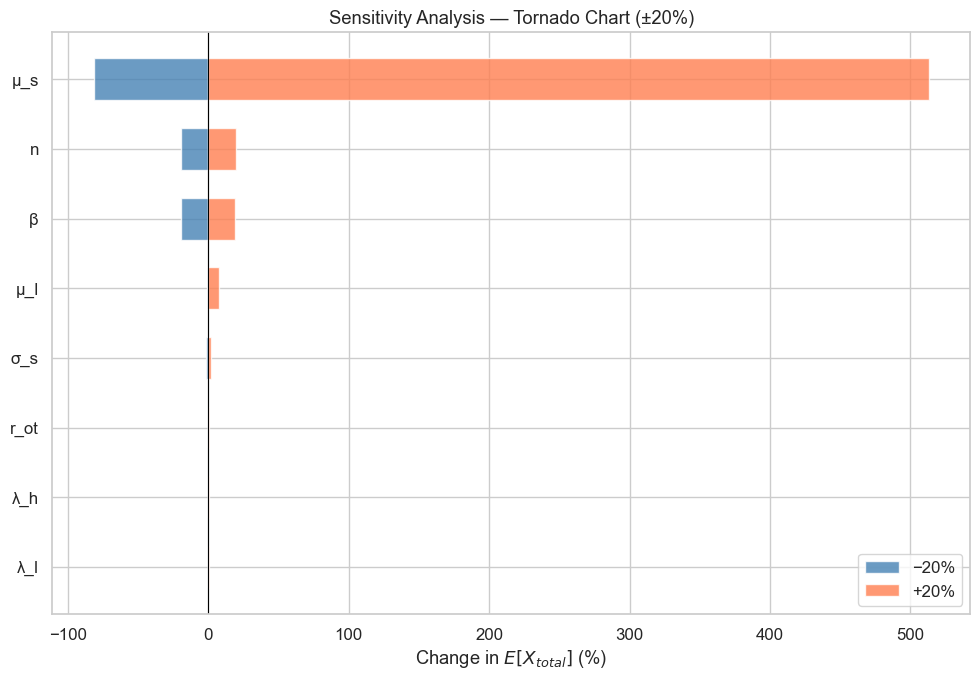

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
y_pos = np.arange(len(labels))

ax.barh(y_pos, low_deltas, height=0.6, color="steelblue", alpha=0.8, label="−20%")
ax.barh(y_pos, high_deltas, height=0.6, color="coral", alpha=0.8, label="+20%")
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel("Change in $E[X_{total}]$ (%)")
ax.set_title("Sensitivity Analysis — Tornado Chart (±20%)")
ax.axvline(0, color="black", lw=0.8)
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("../figures/sensitivity_tornado.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Key Findings Summary

| Finding | Value |
|---------|-------|
| Analytical E[X] | ~R$ 11.55M |
| MC mean (N=50K) | Matches within <0.5% |
| 95% CI half-width | ~R$ 4–5K |
| P5–P95 range | ~R$ 1.6M spread |
| P(over R$ 12.5M ceiling) | See output above |
| Most sensitive parameter | μ_s (salary log-mean) |
| Best variance reduction | Control variates (~10x) |

### What a point estimate misses

A spreadsheet says "R$ 11.55M". Monte Carlo says:
- Full distribution shape (right-skewed)
- Confidence interval for the mean
- Probability of exceeding any budget ceiling
- Which parameters drive uncertainty
- How to reduce estimation error efficiently